In [1]:
import numpy as np
from glob import glob
import pickle
import matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import math
# import datetime
# import time
from scipy.io import readsav
from pandas.core.common import flatten
from scipy import spatial, constants
import pyart
import pandas
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
def outside_of_coords(point, coordinates):
    #3d point with format x, y, z
    #Bounding coordinates of the model domain, of the format X+, X-, Y+, Y-, Z+, Z-
    bound = 0
    if point[0] > coordinates[0]:
        bound = 1
    if point[0] < coordinates[1]:
        bound = 1        
    if point[1] > coordinates[2]:
        bound = 1
    if point[1] < coordinates[3]:
        bound = 1
    if point[2] > coordinates[4]:
        bound = 1
    if point[2] < coordinates[5]:
        bound = 1
    return bound
def knb_mc_sim(m,concentration,size,PROFILE_IN,tree,masktree, LAM_arr,SEEDER = 10.,
               LIMIT = 100.,
               HOMOGENEOUS = False,TOL = 0.1,
               coords = [40e3,0.,40e3,0.,20e3,0.], 
               origin = [5e3,5e3,5e3]):

    
    #origin order is [z,y,x] because gridcoords is z,y,x
    print(origin)
    previousloc = 0 #0 for out of cloud, 1 for in cloud
    currentloc = 0 #0 for out of cloud, 1 for in cloud
    # print(coords)
    #coords is xmax,xmin, ymax,ymin, zmax,zmin
    #Find the dx, dy, dz
    dx = PROFILE_IN['x'][1].values - PROFILE_IN['x'][0].values
    dy = PROFILE_IN['y'][1].values - PROFILE_IN['y'][0].values
    dz = PROFILE_IN['z'][1].values - PROFILE_IN['z'][0].values
    
    
    #Define your boundaries and arrays to hold when a boundary is crossed, specifically if using a hard lateral or vertical boundary
    s = np.size(coords)
    
    ##########CONSTANTS###########
    #Asymmetry factor for a 10micron water drop in the visible spectral region.
    g = 0.87 #double?
    #single scattering albedo for a water droplet of 10 microns in the visible spectral region.
    w_0 = 0.99998

    #the radius of a typical cloud droplet
    a = 10**-5. #evaluate if e is a double, or long
    N = 10**8.
    LAM = 1./(2.*np.pi*(a**2.)*N)

    
    #####calculate the array of possible scattering angles using the Henyey-Greenstein phase function
    N = 2001#e0
    mu_arr = np.zeros(N)
    mu_arr[0] = -1.#formerly 0D
    for i in np.arange(1,len(mu_arr)-1):
        mu_arr[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr[i] > 1.:
            mu_arr[i] = 1.


    pp = np.arange(len(mu_arr),dtype = int)
    #*********
    
    x_arr = np.zeros(m) #array of xyz positions of final location
    y_arr = np.zeros(m)
    z_arr = np.zeros(m)
    xprev_arr = np.zeros(m) #array of xyz positions of second to last location
    yprev_arr = np.zeros(m)
    zprev_arr = np.zeros(m)
    # zenith_arrout = np.zeros(m) 
    # azimuth_arrout = np.zeros(m)
    absorb_flag = np.zeros(m) #0 for scattered through, 1 for if the photon is absorbed
    dist = np.zeros(m) #distance traveled from emission to point of last scattering
    k_arr = np.zeros(m) #number of segments between emission and final position. If 1, no scattering occurred
 
    seed1 = SEEDER
    seed2 = seed1 + 1
    seed3 = seed2 + 2
    seed4 = seed3 + 3
    seed5 = seed4 + 4
    seed6 = seed5 + 5
    seed7 = seed6 + 6
    seed8 = seed7 + 7
    seed9 = seed8 + 8

    #11/13/2024 Changed phi and theta to azimuth and zenith angles naming convention
    #11/13/2024 Note Phi is the angle from the positive x axis, theta is the angle from the positive z axis. This may be backwards from other conventions
    #changed on on 8/6/2024
    #;initial photon isotropically scattered directions
    rng = np.random.default_rng(seed = seed1)
    u = rng.uniform(0,1,m)#randomu(seed1,m)
    rng = np.random.default_rng(seed = seed2)
    azimuth_0 = rng.uniform(0,2.*math.pi,m)#v = randomu(seed2,m) 
    rng = np.random.default_rng(seed = seed3)
    coszenith = rng.uniform(-1,1,m)
    zenith_0 = np.arccos(coszenith)
    rng = np.random.default_rng(seed = seed4)
    ab_arr_m = rng.uniform(0,1, m)
    rng = np.random.default_rng(seed = seed5)
    r_m = rng.uniform(0,1,m) 
       


    #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
    LAM = LAM_arr[tree.query(origin)[1]]
    # LAM = 70. #uncomment for homogeneous atmosphere for funsies
    print(LAM)
    x_scat_0 = -LAM*np.log(r_m)
    
    #two cases:
    #1 Emitted in the cloud: 
    #1 emitted out of the cloud
    point = masktree.query(origin)
    if point[0] < LIMIT:
        currentloc = 1
    else: currentloc = 0

    rng = np.random.default_rng(seed = seed6)
    ind_m = rng.uniform(0,1,m) 
    

    rng = np.random.default_rng(seed = seed7)
    zenith_ind_m_seed = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed8)
    azimuth_r_m = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed9)
    r_m_1 = rng.uniform(0,1,m)
        
    for j in np.arange(m): 
        if (j % 10) == 0:
            print(j)

        counter = 0
        bound = 0
        k=0
        rng = np.random.default_rng(seed = (ab_arr_m[j]*100).astype(int))
        ab_arr = rng.uniform(0,1, 2000000)
    
        if not np.logical_and(zenith_0[j], azimuth_0[j]):
            print('began')#  then begin

            mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
            mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
            mu_z = np.cos(zenith_0[j])

            #;positions
            x = x + x_scat_0[j]*mu_x
            y = y + x_scat_0[j]*mu_y
            z = z + x_scat_0[j]*mu_z
            endif 

        rng_ind = np.random.default_rng(seed = (ind_m[j]*100.).astype(int))
        ind = rng_ind.uniform(0,1,2000)*1999. + 1.
        zenith_arr = np.arccos((mu_arr[pp[1:]] + mu_arr[0:-1])/2.)
        rng = np.random.default_rng(seed = (zenith_ind_m_seed[j]*100.).astype(int))
        zenith_ind = (rng.uniform(0,1,500000)*2000.).astype(int)
        zenith_p = zenith_arr[zenith_ind]
        rng = np.random.default_rng(seed = (azimuth_r_m[j]*100.).astype(int))
        azimuth_p = rng.uniform(0,2*math.pi,500000)
        rng = np.random.default_rng(seed = (r_m_1[j]*100.).astype(int))
        r = rng.uniform(0,1,500000)
        x_scat = -np.log(r)

    
    #First traveled distance  
       
        mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
        mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
        mu_z = np.cos(zenith_0[j])
    
        # ;positions
        xprev = origin[2]
        yprev = origin[1]
        zprev = origin[0]
        
        x = origin[2] + x_scat_0[j]*mu_x
        y = origin[1] + x_scat_0[j]*mu_y
        z = origin[0] + x_scat_0[j]*mu_z
        previousloc = currentloc
        point = masktree.query([z,y,x])
        if point[0]<LIMIT:
            currentloc = 1
        else:
            currentloc = 0
       
 #LOGIC FOR In/Out of cloud options                
        if (previousloc == 0) or (previousloc != currentloc):

            v = [(z - zprev),(y - yprev),(x - xprev)]
            testlam = []
            ptdist = np.sqrt((z-zprev)**2 + (y-yprev)**2 + (x-xprev)**2)

            index = np.arange(500)*(dx/ptdist)
            x1 = xprev + index*v[2]
            y1 = yprev + index*v[1]
            z1 = zprev + index*v[0]
            
            for t in np.arange(500):
                testlam.append((LAM_arr[tree.query([z1[t],y1[t],x1[t]])[1]]))
            newind = np.argmin(np.abs((1+TOL)*LIMIT- np.array(testlam)))   
            if (previousloc == 0) and (currentloc == 0):
                if ~np.any(np.array(testlam) <= (1+TOL)*LIMIT):
                    newind = -1
            min_t = index[newind]
            x = xprev + min_t*v[2]
            y = yprev + min_t*v[1]
            z = zprev + min_t*v[0]
#     #The position has now been updated to the cloud boundary, we can reset and scatter again.
            LAM = testlam[newind]
             

        dist[j] += np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)
        if outside_of_coords([z,y,x], coords):
            # print('ending because bounds')
            x_arr[j] = x
            y_arr[j] = y
            z_arr[j] = z
            xprev_arr[j] = xprev
            yprev_arr[j] = yprev
            zprev_arr[j] = zprev
            k_arr[j]=k
            continue

        while bound < 1: 
            counter +=1
            # ;check to see if absorbed
            if ab_arr[k] > w_0: absorb_flag[j] = 1 # += 1
            if ab_arr[k] > w_0: break


# ;Find the photon's second position
# ;direction cosines
            denom = np.sqrt(1. - mu_z**2.)
            mu_x_new = ((np.sin(zenith_p[k])*(mu_x*mu_z*np.cos(azimuth_p[k]) - mu_y*np.sin(azimuth_p[k])))/denom) + mu_x*np.cos(zenith_p[k])
            mu_y_new = ((np.sin(zenith_p[k])*(mu_y*mu_z*np.cos(azimuth_p[k]) + mu_x*np.sin(azimuth_p[k])))/denom) + mu_y*np.cos(zenith_p[k])
            mu_z_new = -(denom)*np.sin(zenith_p[k])*np.cos(azimuth_p[k]) + mu_z*np.cos(zenith_p[k])

            if not math.isfinite(z):
                print('broken')
                break
            if not math.isfinite(y):
                print('broken')
                break
            if not math.isfinite(x):
                print('broken')
                break
             
            LAM = LAM_arr[tree.query([z,y,x])[1]]

            xprev = x
            yprev = y
            zprev = z
            x = x + LAM*x_scat[k]*mu_x_new
            y = y + LAM*x_scat[k]*mu_y_new
            z = z + LAM*x_scat[k]*mu_z_new
            mu_x = mu_x_new
            mu_y = mu_y_new
            mu_z = mu_z_new
            k += 1
        

            previousloc = currentloc
            point = masktree.query([z,y,x])
            if point[0]<LIMIT:
                currentloc = 1
            else:
                currentloc = 0
       
 #LOGIC FOR In/Out of cloud options                
            if (previousloc == 0) or (previousloc != currentloc):

                v = [(z - zprev),(y - yprev),(x - xprev)]
                testlam = []
                ptdist = np.sqrt((z-zprev)**2 + (y-yprev)**2 + (x-xprev)**2)

                index = np.arange(500)*(dx/ptdist)
                x1 = xprev + index*v[2]
                y1 = yprev + index*v[1]
                z1 = zprev + index*v[0]
            
                for t in np.arange(500):
                    testlam.append((LAM_arr[tree.query([z1[t],y1[t],x1[t]])[1]]))
                newind = np.argmin(np.abs((1+TOL)*LIMIT- np.array(testlam)))   
                if (previousloc == 0) and (currentloc == 0):
                    if ~np.any(np.array(testlam) <= (1+TOL)*LIMIT):
                        newind = -1
                min_t = index[newind]
                x = xprev + min_t*v[2]
                y = yprev + min_t*v[1]
                z = zprev + min_t*v[0]
#     #The position has now been updated to the cloud boundary, we can reset and scatter again.
                LAM = testlam[newind]
             

            dist[j] += np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)

            if outside_of_coords([z,y,x], coords):
                bound = 1
                
        # dist[j] -= np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)
        x_arr[j] = x
        y_arr[j] = y
        z_arr[j] = z
        xprev_arr[j] = xprev
        yprev_arr[j] = yprev
        zprev_arr[j] = zprev
        k_arr[j]=k
        # print([z,y,x])
    
    # print(absorb)
    array_out =np.column_stack((x_arr,y_arr,z_arr,xprev_arr, yprev_arr, zprev_arr,k_arr,absorb_flag,dist)) #,zenith_arrout,azimuth_arrout))
    return(array_out)#, pathx,pathy,pathz)  

In [6]:
origin = [4062.5,21e3,15e3]
# origin = [5e3,22e3,17e3]
# origin = [5e3,19.5e3,14.5e3]
# origin = [8437.5,19.5e3,14.5e3]
# origin = [4062.5,9000.0,9250.0]

m = 500

profile_in =xr.open_dataset('/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B_30s.002430.nc')
zs = profile_in['z'].values
xs = profile_in['x'].values
ys = profile_in['y'].values
        #make points and kdtree for cloud coordinates
zz,yy,xx = np.meshgrid(profile_in['z'].values, profile_in['y'].values,profile_in['x'].values,indexing='ij')
length = len(profile_in['x'])*len(profile_in['y'])*len(profile_in['z'])
xx = np.reshape(xx,length)
yy = np.reshape(yy,length)
zz = np.reshape(zz,length)
gridcoords = np.stack((zz,yy,xx),axis = 1) 
tree = spatial.KDTree(gridcoords)
    
N_dense = np.reshape(profile_in['particle_concentration'].values,length)
a_arr = np.reshape(profile_in['particle_size'].values,length)
a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile

LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
    # LAM_arr = np.reshape(LAM_arr,[80,10,10])

    #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
mask = np.where(LAM_arr <= 200)
mask = np.array(list(flatten(mask)))
maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
masktree = spatial.KDTree(maskstack)

    

out = knb_mc_sim(m,profile_in['particle_concentration'].values,profile_in['particle_size'].values,profile_in,
                           tree,masktree,LAM_arr,SEEDER  = 10,origin = origin, LIMIT = 500.)

# df = pd.DataFrame(out)
# file_name = 'COMMAS30s_'+str(origin[0])[:-2]+'_'+str(origin[1])[:-2]+'_'+str(origin[2])[:-2]+'_homogeneous.csv'
# print(file_name)
# df.to_csv(file_name, index=False)



/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_66395/807650100.py:32: RuntimeWarning: divide by zero encountered in divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


In [552]:
#Unit tests
# dx = dy = dz = 125.
# previousloc = 0
# LIMIT = 200.
# TOL = 0.25
# #Test cases:
# # Cases: 
#     # prev = 0, current = 0 #must check if passed through a cloud, and if out of bounds
# # previousloc = 0
# # currentloc = 0
# # pt1 = [4062.5, 9000.0, 9250.0]
# # pt2 = [-71660.76224151079, -32109.7144651036, 352478.17026776477]
# #     prev = 0, current = 1 #check for the cloud boundary and reset there
# # previousloc = 0
# # currentloc = 1
# # pt1 = [4062.5, 9000.0, 9250.0]
# # pt2 = [5e3,21e3,15e3]
# #     prev = 1, current = 0 #end simulation no checks, but could check for cloud boundary
# previousloc = 1
# currentloc = 0
# pt1 = [5e3,21e3,15e3]
# pt2 = [4062.5, 9000.0, 9250.0]
# # #     prev = 1, current = 1 #continue simulation no checks
# # pt1 = [5e3,21e3,15e3]
# # pt2 = [5e3,19.5e3,14.5e3]

# xprev = pt1[2]
# yprev = pt1[1]
# zprev = pt1[0]
# z = pt2[0]
# y = pt2[1]
# x = pt2[2]

# LAM = (LAM_arr[tree.query(pt1)[1]])
# print(LAM)

In [523]:
           
# # Cases: 
# #     prev = 0, current = 0 #must check if passed through a cloud, and if out of bounds #Done
# #     prev = 0, current = 1 #check for the cloud boundary and reset there #done
# #     prev = 1, current = 0 #end simulation no checks, but could check for cloud boundary 
# #     prev = 1, current = 1 #continue simulation no checks


# if (previousloc == 0) or (previousloc != currentloc):

#     v = [(z - zprev),(y - yprev),(x - xprev)]
#     testlam = []
#     ptdist = np.sqrt((z-zprev)**2 + (y-yprev)**2 + (x-xprev)**2)

#     index = np.arange(500)*(dx/ptdist)
#     x1 = xprev + index*v[2]
#     y1 = yprev + index*v[1]
#     z1 = zprev + index*v[0]
            
#     for t in np.arange(500):
#         testlam.append((LAM_arr[tree.query([z1[t],y1[t],x1[t]])[1]]))
#     newind = np.argmin(np.abs((1+TOL)*LIMIT- np.array(testlam)))   
#     if (previousloc == 0) and (currentloc == 0):
#         if ~np.any(np.array(testlam) <= (1+TOL)*limit):
#             newind = -1
#             # bound = 1 #if there's nothing in the path just quit the photon 
#     min_t = index[newind]
#     x = xprev + min_t*v[2]
#     y = yprev + min_t*v[1]
#     z = zprev + min_t*v[0]
# #     #The position has now been updated to the cloud boundary, we can reset and scatter again.
#     LAM = testlam[newind]
 


# print([previousloc, currentloc])
# print(pt1)
# print(pt2)
# print([z,y,x])
# print(LAM)
    

[1, 0]
[5000.0, 21000.0, 15000.0]
[4062.5, 9000.0, 9250.0]
[4789.159507548751, 18301.241696624013, 13706.84497963234]
256.360393620456


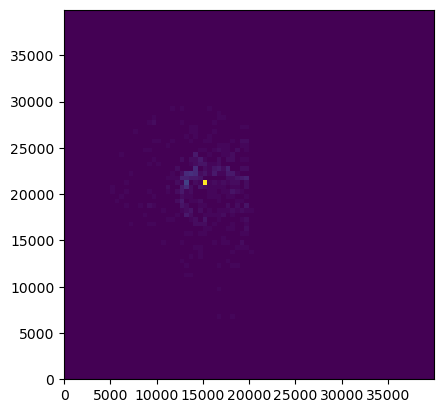

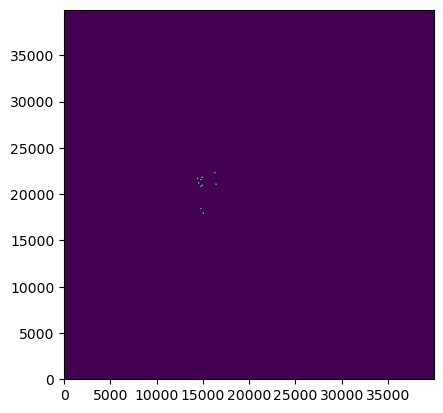

In [616]:
#creates 2 heatmaps, one of absorption and one of emission (exiting the cloud)

# out = pandas.read_csv("COMMAS30s_4062_21000_15000.csv").to_numpy() #array_out[0:50000,:]
# out = out[0:50000,:]
#EMITTED
outgrid = np.zeros([len(profile_in['x'])])
# grid_z2 = griddata(out[zp,0]/1e3,out[zp,1]/1e3, values, (grid_x, grid_y), method='cubic')
import numpy as np
import numpy.random
import matplotlib.pyplot as plt

x = out[:,3] #4
y = out[:,4]#3
heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(profile_in['x'])], [0, np.nanmax(profile_in['x'])]],bins = [80,80],density = False)

extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

plt.clf()
plt.imshow(heatmap, extent=extent, origin='lower')
plt.show()

#ABSORBED
outgrid = np.zeros([len(profile_in['x']),len(profile_in['x'])])
# zp = list(flatten((dist <= 500.)))
zp = list(flatten(np.where(out[:,-2] ==1)))
# Generate some test data
x = out[zp,0]
y = out[zp,1]

heatmap5, xedges5, yedges5 = np.histogram2d(y, x, range=[[0, np.nanmax(profile_in['x'])], [0, np.nanmax(profile_in['x'])]],bins = [len(profile_in['x']),len(profile_in['x'])],density = True)
extent = [0, np.nanmax(profile_in['x']),0, np.nanmax(profile_in['x'])]

plt.clf()
plt.imshow(heatmap5, extent=extent, origin='lower')
plt.show()

In [186]:
MFP = np.reshape(LAM_arr, [160,320,320])
arr = np.zeros([320,320])
mfp2d =np.zeros([320,320])

for j in np.arange(320): #y
    for i in np.arange(320): #x
        arr[j,i] =125.*(len(np.where(MFP[:,j,i] <=200.)[0]))
        p = np.where(MFP[:,j,i]<=200.)
        # mfp2d[i,j] = 70.44#np.nanmean(MFP[p,i,j])
        mfp2d[j,i] = np.nanmedian(MFP[p,j,i])
tau = (arr/mfp2d)


/Users/kelcy/opt/anaconda3/envs/PAWS39/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


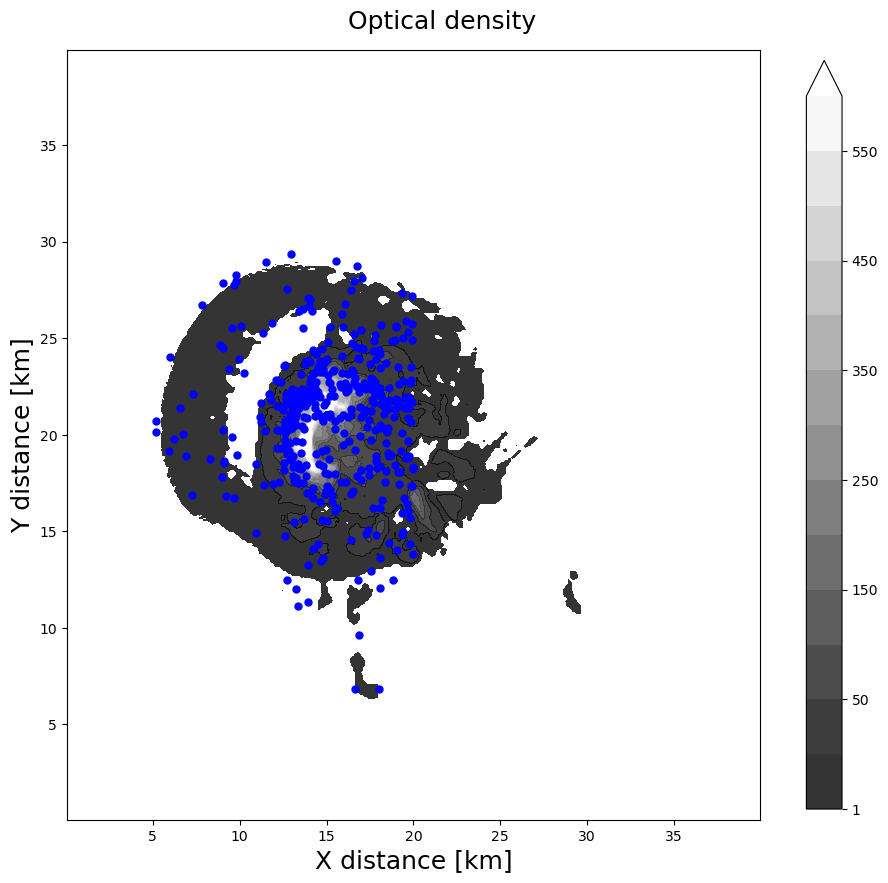

In [618]:

maxrefl = data['DBZ'].max(axis=1)
# mean_mfp = MFP.mean(axis = 0)
frame = 0

ref_levels = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75]

photon_levels=[1,3,5,10,20,30,40,50,60,70,80,90,100]

lambda_levels = [1,2,3,5,10,15,25,50,75,100,150,200,350,500,600,800,1000]
tau_levels = [1,10,50,100,150,200,250,300,350,400,450,500,550,600]
lambda_levels = [1,2,3,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,125,150,175,200]#25,50,75,100]#,350,500,600,800,1000]
tau_levels = [1,10,50,100,150,200,250,300,350,400,450,500,550,600]

fig, ax = plt.subplots(figsize=(10,10))

refl = maxrefl[0,:,:]#maxrefl[frame,:,:]
# fig.suptitle(str(end))
# fig.suptitle('Light escaping the cloud (%), and 10cm simulated radar reflectivity', fontsize=18,y=0.92)
fig.suptitle('Optical density', fontsize=18,y=0.92)
# x_mesh, y_mesh = np.meshgrid(profile_in['x'],profile_in['y'])
y_mesh, x_mesh = np.meshgrid(profile_in['y'],profile_in['x'])
# ymesh2,xmesh2=np.meshgrid(xedges[0:80],yedges[0:80])

# refplt = ax.contourf(y_mesh/1e3,x_mesh/1e3, refl, extend = 'max',levels = ref_levels,cmap='pyart_LangRainbow12',origin = 'lower', vmin=-24, vmax=72, alpha = 0.9)#,extent = [0,-10000,-20000,-10000])
tauplt = ax.contourf(y_mesh/1e3,x_mesh/1e3, tau, extend = 'max',levels = tau_levels,cmap='gist_gray',origin = 'lower',alpha = 0.8)#,extent = [0,-10000,-20000,-10000])
fig.colorbar(tauplt,fraction=0.046, pad=0.06)


origin = [5e3,21e3,15e3]
# pt3 = ax.scatter(origin[2]/1e3,origin[1]/1e3,marker = 'o' ,color = 'blue',s = 45.0)
for i,val in enumerate(out[:,-1]):
    ax.scatter(out[i,3]/1e3,out[i,4]/1e3,marker = 'o' ,color = 'blue',s = 25.0)
ax.set_xlabel('X distance [km]',fontsize = 18)
ax.set_ylabel('Y distance [km]',fontsize = 18)
# ax.scatter(out[:,0], out[:,1], out[:,2])
# ax.set_ylim(0,15)
# ax.set_xlim(3,35)
# ax.set_xlim(3,35)
# ax.set_ylim(3,33)
plt.show()
savedir = ""
# fig.savefig(savedir+'tau_20250331.pdf',format = 'pdf',dpi=1200)



In [4]:
#Evaluate the time delay the photons experienced between emission and exiting the cloud or absorption
tdelay = out[:,-1]/constants.c
# tdelay = newdist/constants.c
print(np.nanmean(tdelay)*1e6)
print(np.median(tdelay)*1e6)
# tdelay*(10**(6))
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1)#, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs.hist(tdelay*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
                                  210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
                                  410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# axs[1].hist(dist2, bins=n_bins)
axs.set_xlabel('Time delay in Microseconds')
axs.set_ylabel('Count')

plt.show()


NameError: name 'out' is not defined